In [1]:
import jax
import jax.numpy as jnp
import lz4
import lz4.frame
import cloudpickle
import functools as ft

from matplotlib import pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

To jest spakowana struktura, więc żeby ją wczytać:

In [2]:
with lz4.frame.open('history_10_10_42.pkl.lz4', 'rb') as f:
    carry, history = cloudpickle.load(f)

Dodatkowo tam jest zaaplikowany vmap, więc żeby dostać się do parametrów agenta "i" trzeba:

In [3]:
i=2
t=3
params_i = {'params': jax.tree.map(lambda x: x[i], carry.drl_states).params}

Natomiast obserwacja z kroku "t" dla agenta "i" to klasycznie:

In [4]:
env_state = history.observations[t][i]

A reszta wiadomo, prosty model flaxowy, który importujemy z:

In [5]:
from ltc.agents.drl import QNetwork

In [6]:
qnetwork = QNetwork()


In [7]:
qnetwork.apply(params_i, env_state)

Array([[2.506735 , 1.3591919]], dtype=float32)

In [8]:
@jax.jit
@ft.partial(jax.vmap, in_axes=(None,0))
@ft.partial(jax.vmap, in_axes=(0,0))
def apply(params, state):
    return qnetwork.apply(params, state)


params = {'params': carry.drl_states.params}
q = apply(params, history.observations)
#apply(params_i, env_state)

In [9]:
q.shape

(10000, 10, 1, 2)

In [10]:
def plot_q(q):
    fig, axs = plt.subplots(nrows=q.shape[1], sharex=True, sharey=True, figsize=(4, 40))

    for i,ax in enumerate(axs):
        ax.scatter(q[:,i,0,0],q[:,i,0,1], alpha=0.1)
        ax.set_aspect('equal')
        ax.set_title(f'agent{i}')


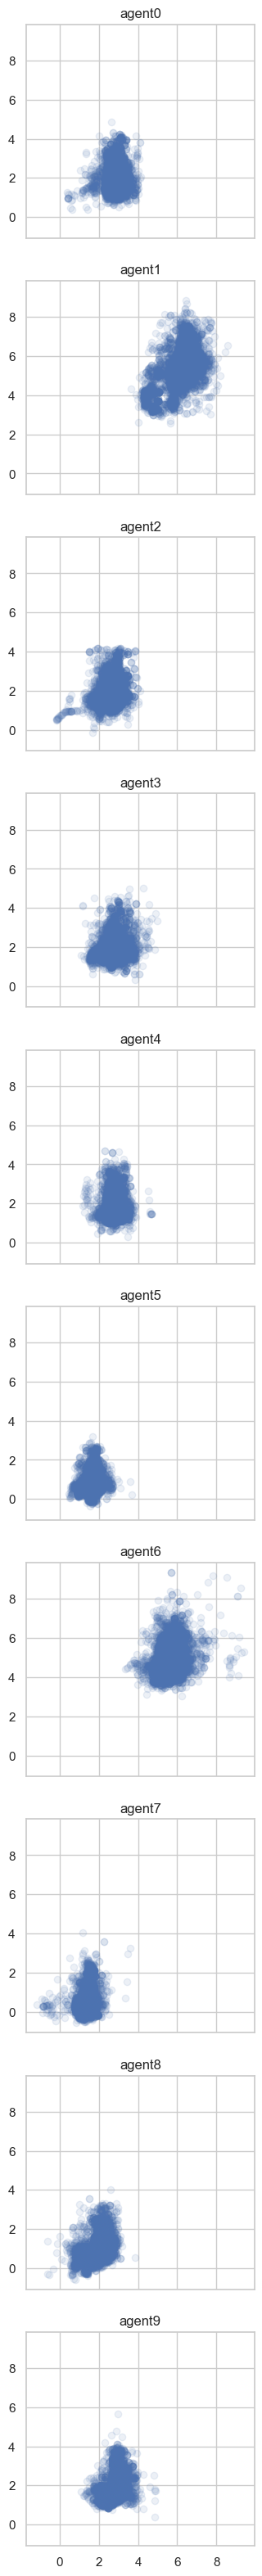

In [11]:
plot_q(q)

# Average

In [12]:
def avergae_parasm(x):
    a = jnp.mean(x, axis=0, keepdims=True)
    y = jnp.repeat(a, x.shape[0], axis=0)
    return y
aparams = jax.tree.map(avergae_parasm, params)

aq = apply(aparams, history.observations)

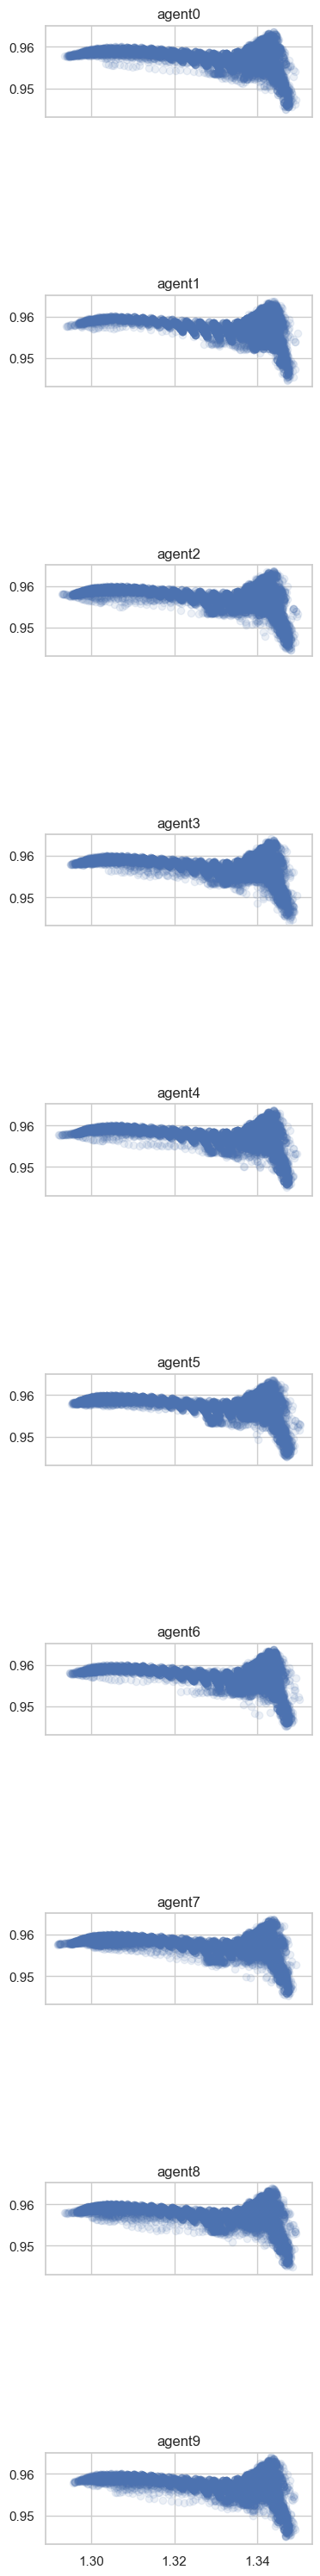

In [13]:
plot_q(aq)

In [14]:

def take_n(x,n):
    a = x[n]
    a = jnp.expand_dims(a, 0)
    y = jnp.repeat(a, x.shape[0], axis=0)
    return y

In [15]:
p=jax.tree.map(ft.partial(take_n,n=0), params)
q=apply(p, history.observations)

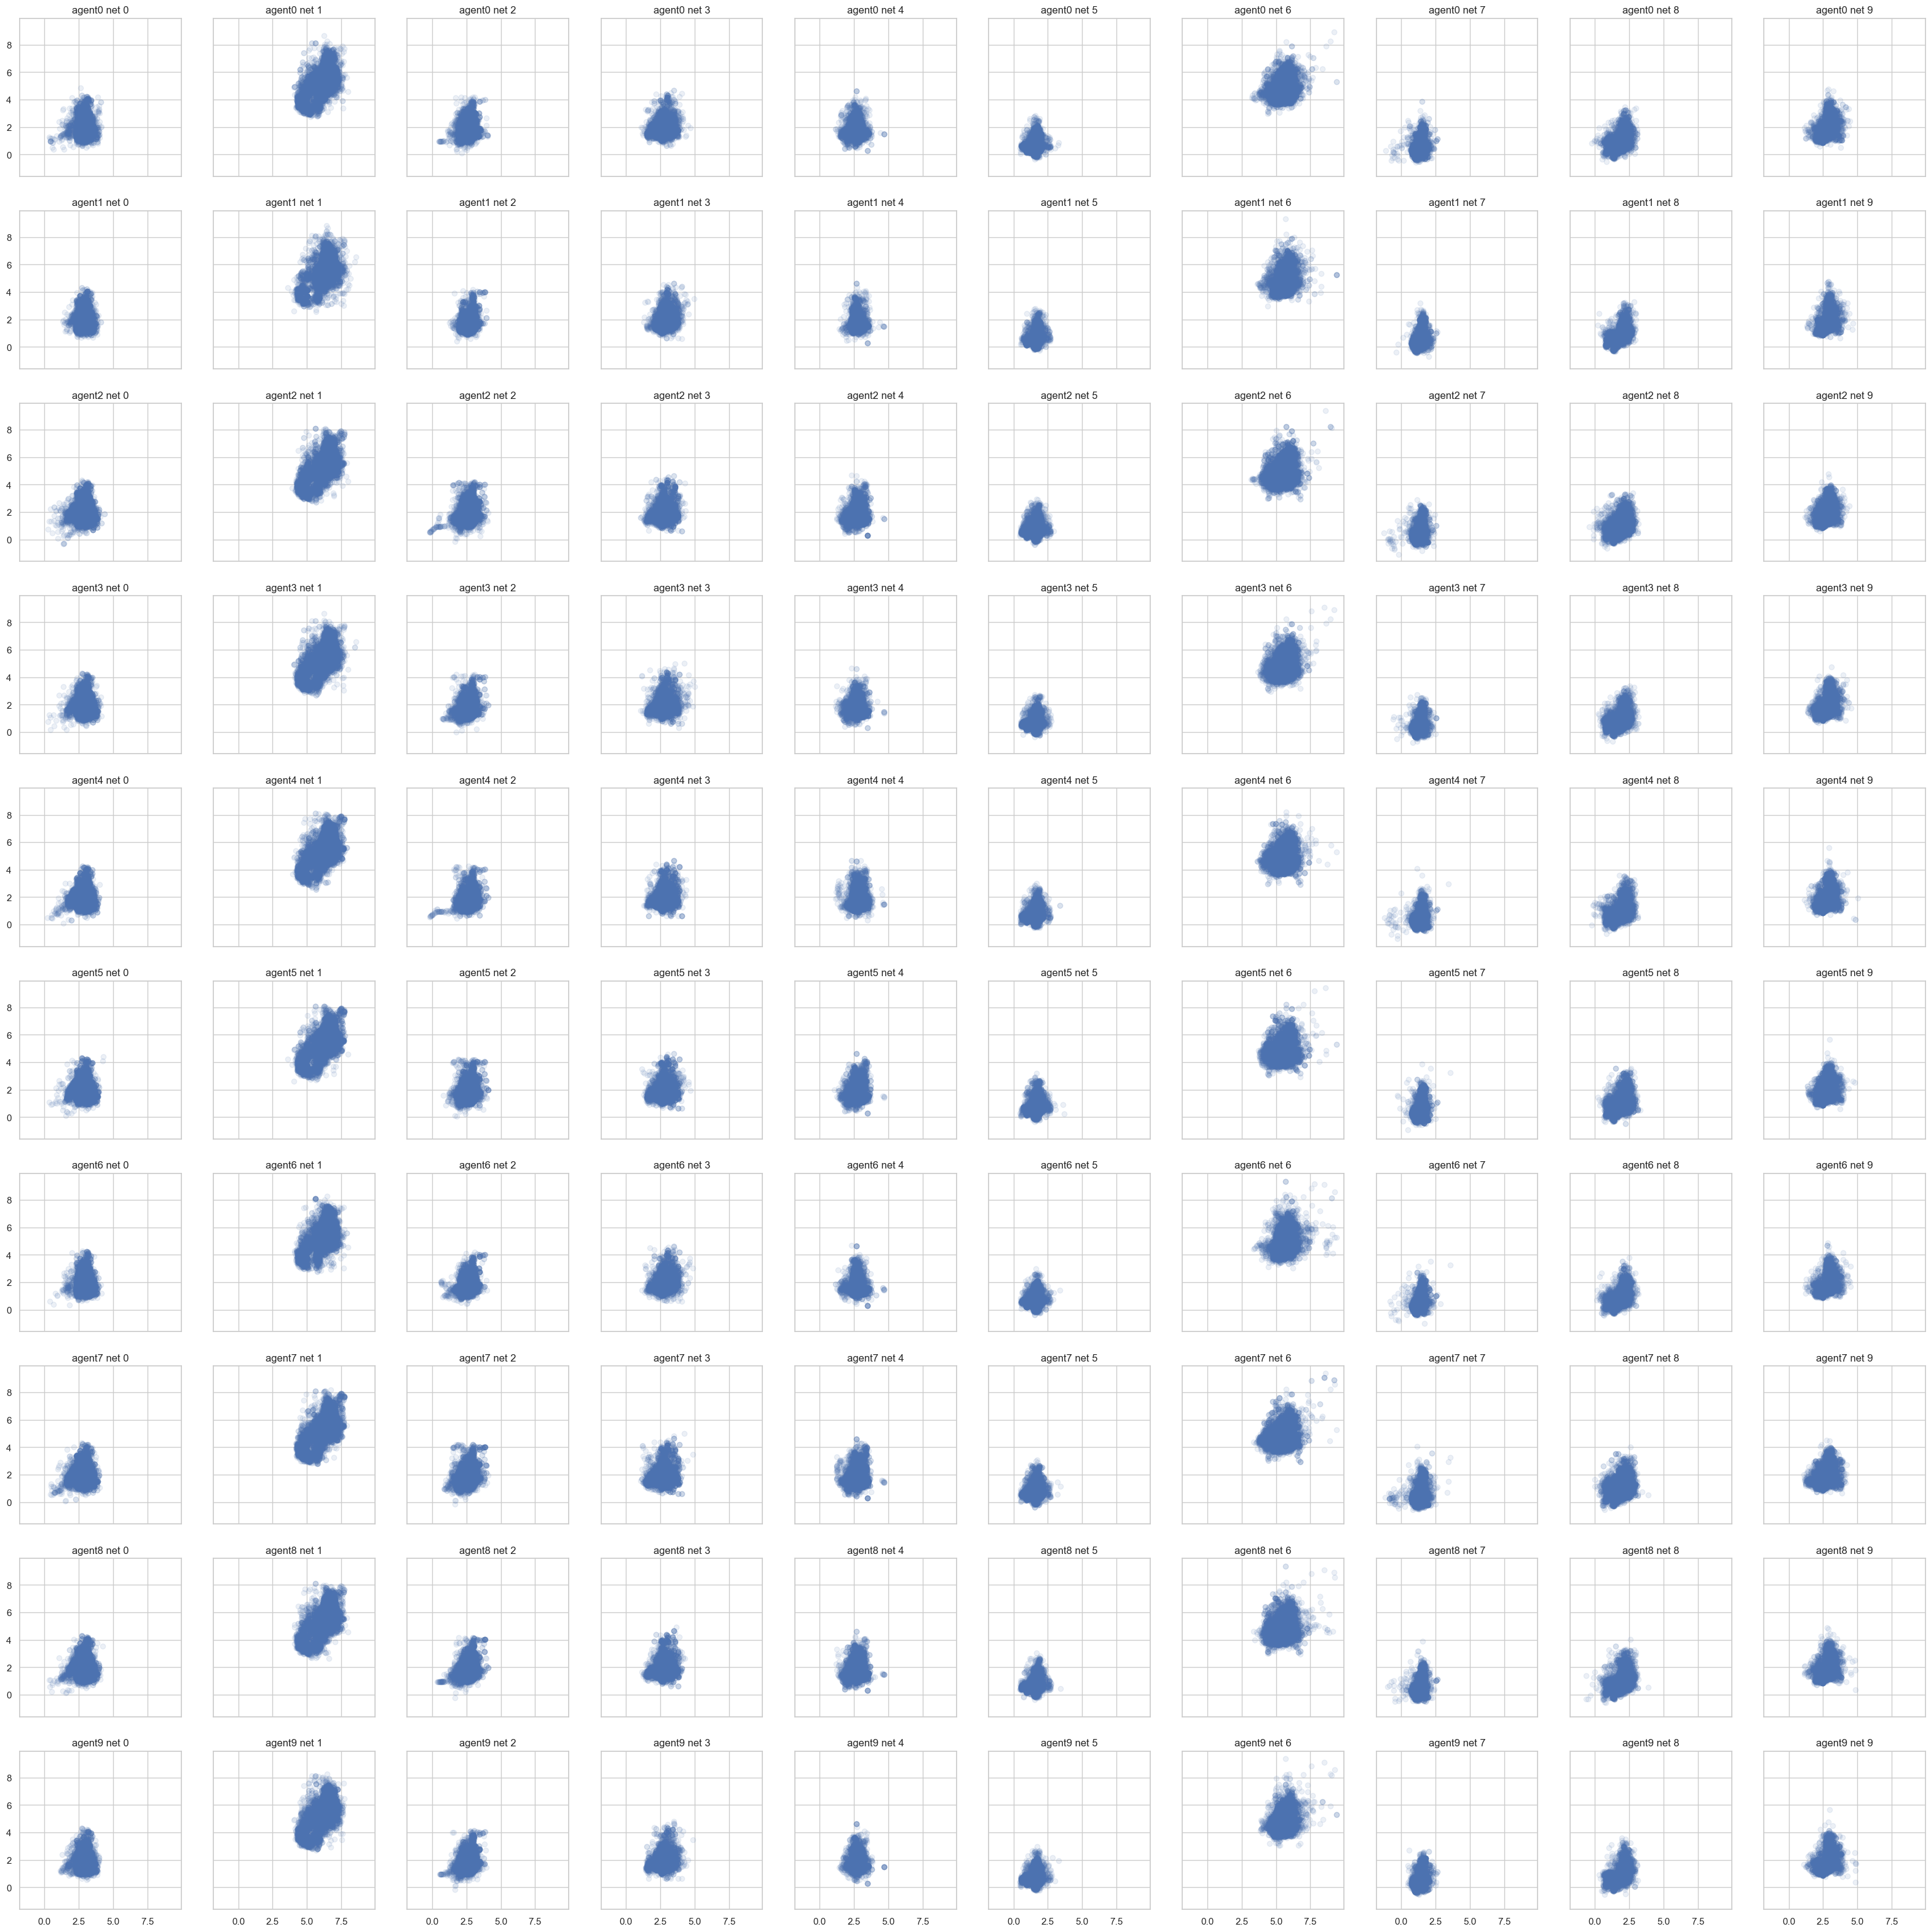

In [16]:
fig, axs = plt.subplots(nrows=10,ncols=10, sharex=True, sharey=True, figsize=(40, 40))

for i in range(10):
    for j in range(10):
        ax = axs[i,j]
        p = jax.tree.map(ft.partial(take_n,n=j), params)
        q=apply(p, history.observations)
        ax.scatter(q[:,i,0,0],q[:,i,0,1], alpha=0.1)
        ax.set_aspect('equal')
        ax.set_title(f'agent{i} net {j}')